# Install library in environment

In [1]:
!pip install jupedsim pedpy

# Setup your drive
- if use google colab

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Example code from official

In [1]:
import pathlib

import jupedsim as jps
import matplotlib.pyplot as plt
import pandas as pd
import pedpy
from numpy.random import normal  # normal distribution of free movement speed
from shapely import GeometryCollection, Polygon

In [2]:
geo_corridor = "/content/drive/MyDrive/CU/Thesis/AI_Data/PedSim_Bottleneck/Topo 02/geo_corridor.json"
geo_room = "/content/drive/MyDrive/CU/Thesis/AI_Data/PedSim_Bottleneck/Topo 02/geo_room.json"

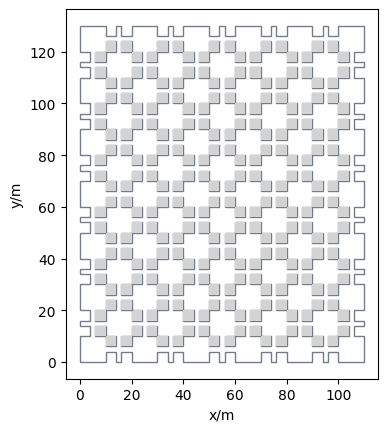

In [3]:
################
# Geometry setup
################
import json
from shapely.geometry import Polygon
from shapely.ops import unary_union
import pedpy

# 1. ฟังก์ชันสำหรับโหลด JSON และแปลงเป็น List ของ Shapely Polygons
def load_polygons_from_json(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    # ข้อมูลในไฟล์คุณเป็น list ของ list พิกัด [[ [x,y], [x,y]... ], [...]]
    return [Polygon(poly_coords) for poly_coords in data]

# 2. โหลดข้อมูล (เปลี่ยนชื่อไฟล์ตามที่คุณเซฟไว้)
corridor_polys = load_polygons_from_json(geo_corridor)
room_polys = load_polygons_from_json(geo_room)

# 3. รวม Geometry ทั้งหมดเข้าด้วยกัน (Boolean Union)
# unary_union จะรวมก้อนที่ทับกันให้กลายเป็นชิ้นเดียวอัตโนมัติ
all_geoms = corridor_polys + room_polys
all_areas = unary_union(all_geoms)
area = all_areas
# 4. สร้าง Walkable Area สำหรับ PedPy
walkable_area = pedpy.WalkableArea(all_areas)

# 5. แสดงผลตรวจสอบ
pedpy.plot_walkable_area(walkable_area=walkable_area).set_aspect("equal")

In [4]:
################
# Define start and destination
################
import json
import random
from shapely.geometry import Polygon

# 1. โหลดข้อมูลห้องทั้งหมดจาก JSON
with open(geo_room, 'r') as f:
    room_data = json.load(f)

# แปลงเป็น List ของ Shapely Polygons
all_rooms = [Polygon(pts) for pts in room_data]

################
# Random Setup with Seed
################
SEED_VALUE = 1  # เปลี่ยนตัวเลขนี้เพื่อเปลี่ยนรูปแบบการสุ่ม (ถ้าใส่เลขเดิมจะได้ห้องเดิม)
rand_gen = random.Random(SEED_VALUE)

# สุ่มเลือก 2 ห้องจากทั้งหมดโดยไม่ซ้ำกัน (sample จะคืนค่าเป็น List [ห้องที่1, ห้องที่2])
selected_rooms = rand_gen.sample(all_rooms, k=2)

spawning_area = selected_rooms[0]  # ห้องสำหรับเริ่ม
exit_area = selected_rooms[1]      # ห้องสำหรับออก

print(f"Spawning Area Selected: {spawning_area.centroid}")
print(f"Exit Area Selected: {exit_area.centroid}")

################
# Define Agents in Spawning Area
################
num_agents = 100

# ใช้ jps หรือ pedpy ในการกระจายคน
# (ตรวจสอบว่าใน Library ที่คุณใช้ใช้ parameter ชื่ออะไร ในที่นี้อิงตามตัวอย่างที่คุณส่งมา)
pos_in_spawning_area = jps.distributions.distribute_by_number(
    polygon=spawning_area,
    number_of_agents=num_agents,
    distance_to_agents=0.3,
    distance_to_polygon=0.15,
    seed=SEED_VALUE, # ใช้ seed เดียวกันเพื่อให้ตำแหน่งคนคงที่ด้วย
)

# ส่วนของ exit_area คุณสามารถนำไปใช้สร้าง Measurement Line
# หรือ Destination สำหรับ PedPy ต่อได้เลยครับ

Spawning Area Selected: POINT (95 35)
Exit Area Selected: POINT (45 25)


In [5]:
################
# Hidden function
################
def plot_simulation_configuration(
    walkable_area, spawning_area, starting_positions, exit_area
):
    axes = pedpy.plot_walkable_area(walkable_area=walkable_area)
    axes.fill(*spawning_area.exterior.xy, color="lightgrey")
    axes.fill(*exit_area.exterior.xy, color="indianred")
    axes.scatter(*zip(*starting_positions), s=1)
    axes.set_xlabel("x/m")
    axes.set_ylabel("y/m")
    axes.set_aspect("equal")

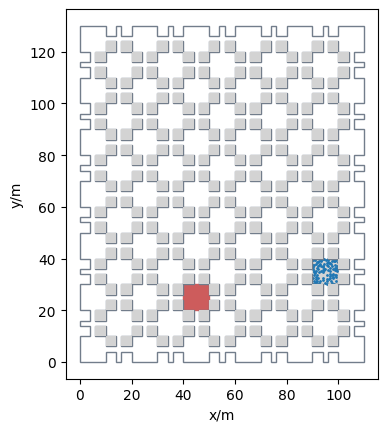

In [6]:
################
# Show prepare data at all
################
plot_simulation_configuration(
    walkable_area, spawning_area, pos_in_spawning_area, exit_area
)

In [7]:
trajectory_file = f"/content/drive/MyDrive/CU/Thesis/AI_Data/PedSim_Bottleneck/Topo 02/double-botteleneck_{SEED_VALUE}.sqlite"  # output file
simulation = jps.Simulation(
    model=jps.CollisionFreeSpeedModel(),
    geometry=area,
    trajectory_writer=jps.SqliteTrajectoryWriter(
        output_file=pathlib.Path(trajectory_file)
    ),
)

exit_id = simulation.add_exit_stage(exit_area.exterior.coords[:-1])
journey = jps.JourneyDescription([exit_id])
journey_id = simulation.add_journey(journey)

In [11]:
################
# Specification of Parameters reference Social force model(Helbing, 1998)
################
v_distribution = normal(1.34, 0.05, num_agents)

for pos, v0 in zip(pos_in_spawning_area, v_distribution):
    simulation.add_agent(
        jps.CollisionFreeSpeedModelAgentParameters(
            journey_id=journey_id,
            stage_id=exit_id,
            position=pos,
            desired_speed=v0,
            radius=0.15,
        )
    )

while simulation.agent_count() > 0:
    simulation.iterate()
simulation._writer.close()

In [32]:
################
# Visualization trajactory
################
from jupedsim.internal.notebook_utils import animate, read_sqlite_file

trajectory_data, walkable_area = read_sqlite_file(trajectory_file)
animate(trajectory_data, walkable_area)

# Save to png and combine MP4

In [ ]:
!pip install imageio imageio-ffmpeg

In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(trajectory_file)

df = pd.read_sql_query(
    "SELECT frame, id, pos_x, pos_y FROM trajectory_data",
    conn
)

df.head()

,frame,id,pos_x,pos_y
0,0,1,2.085110,7.203245
1,0,2,0.733779,0.923386
2,0,3,0.931301,3.455607
3,0,4,1.983837,5.388167
4,0,5,2.095973,6.852195


In [ ]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import pedpy

# read trajectory
conn = sqlite3.connect(trajectory_file)

df = pd.read_sql_query(
    "SELECT frame, id, pos_x, pos_y FROM trajectory_data",
    conn
)

# read walkable area from sqlite
traj = pedpy.load_trajectory_from_jupedsim_sqlite(
    trajectory_file=pathlib.Path(trajectory_file)
)

walkable_area = pedpy.load_walkable_area_from_jupedsim_sqlite(
    trajectory_file=pathlib.Path(trajectory_file)
)

# output folder
out_dir = "frames"
os.makedirs(out_dir, exist_ok=True)

frames = sorted(df["frame"].unique())

for f in tqdm(frames):

    frame_data = df[df["frame"] == f]

    fig, ax = plt.subplots(figsize=(8,4))

    # plot floor / geometry
    pedpy.plot_walkable_area(
        walkable_area=walkable_area,
        axes=ax
    )

    # plot agents
    ax.scatter(
        frame_data["pos_x"],
        frame_data["pos_y"],
        s=20,
        color="blue"
    )

    ax.set_title(f"Frame {f}")
    ax.set_aspect("equal")

    plt.savefig(f"{out_dir}/frame_{f:05d}.png")
    plt.close()

100%|██████████| 2808/2808 [06:39<00:00,  7.02it/s]


In [ ]:
import imageio
import os

files = sorted(os.listdir("frames"))

images = []

for f in files:
    if f.endswith(".png"):
        images.append(imageio.imread(f"frames/{f}"))

imageio.mimsave("bottleneck.mp4", images, fps=25)

/tmp/ipykernel_24706/1188702049.py:10: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(f"frames/{f}"))


#Viz to analysis

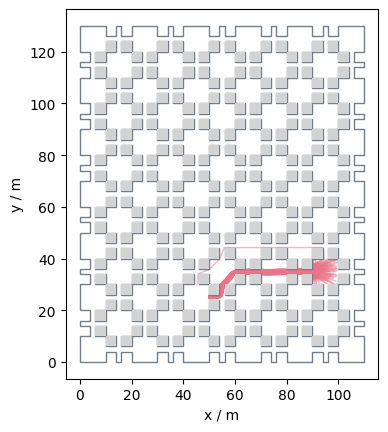

In [23]:
from jupedsim.internal.notebook_utils import animate, read_sqlite_file

trajectory_data, walkable_area = read_sqlite_file(trajectory_file)

pedpy.plot_measurement_setup(
    walkable_area=walkable_area,
    traj=trajectory_data,
    traj_alpha=0.5,
    traj_width=1,
    ml_color="b",
    ma_line_width=1,
    ma_alpha=0.2,
).set_aspect("equal")

In [11]:
individual_speed = pedpy.compute_individual_speed(
    traj_data=trajectory_data,
    frame_step=5,
    speed_calculation=pedpy.SpeedCalculation.BORDER_SINGLE_SIDED,
)

individual_voronoi_cells = pedpy.compute_individual_voronoi_polygons(
    traj_data=trajectory_data,
    walkable_area=walkable_area,
    cut_off=pedpy.Cutoff(radius=0.8, quad_segments=3),
)

In [21]:
import numpy as np
from tqdm.auto import tqdm

merged_data = pd.merge(individual_voronoi_cells, individual_speed, on=["id", "frame"])

# 1. เตรียมตัวแปรสำหรับบวกสะสม
sum_density = None
sum_speed = None
count = 0
frame_n = 60
grid_size = 0.5
frames_to_process = merged_data['frame'].unique()[::frame_n]

# 3. วนลูปประมวลผล
for f in tqdm(frames_to_process, desc="กำลังคำนวณ Heatmap แบบ Skip Frame"):
    frame_data = merged_data[merged_data.frame == f]

    d_profile, s_profile = pedpy.compute_profiles(
        individual_voronoi_speed_data=frame_data,
        walkable_area=walkable_area.polygon,
        grid_size=grid_size,
        speed_method=pedpy.SpeedMethod.ARITHMETIC,
    )
    # บวกสะสม Density
    if sum_density is None:
        sum_density = np.copy(d_profile[0])
        sum_speed = np.copy(s_profile[0])
    else:
        sum_density += d_profile[0]
        sum_speed += s_profile[0]

    count += 1

# 2. หารเฉลี่ยตอนจบ
if count > 0:
    mean_density_map = sum_density / count
    mean_speed_map = sum_speed / count
    print("คำนวณค่าเฉลี่ยเสร็จทั้งคู่แล้ว!")

กำลังคำนวณ Heatmap แบบ Skip Frame:   0%|          | 0/41 [00:00<?, ?it/s]

คำนวณค่าเฉลี่ยเสร็จทั้งคู่แล้ว!


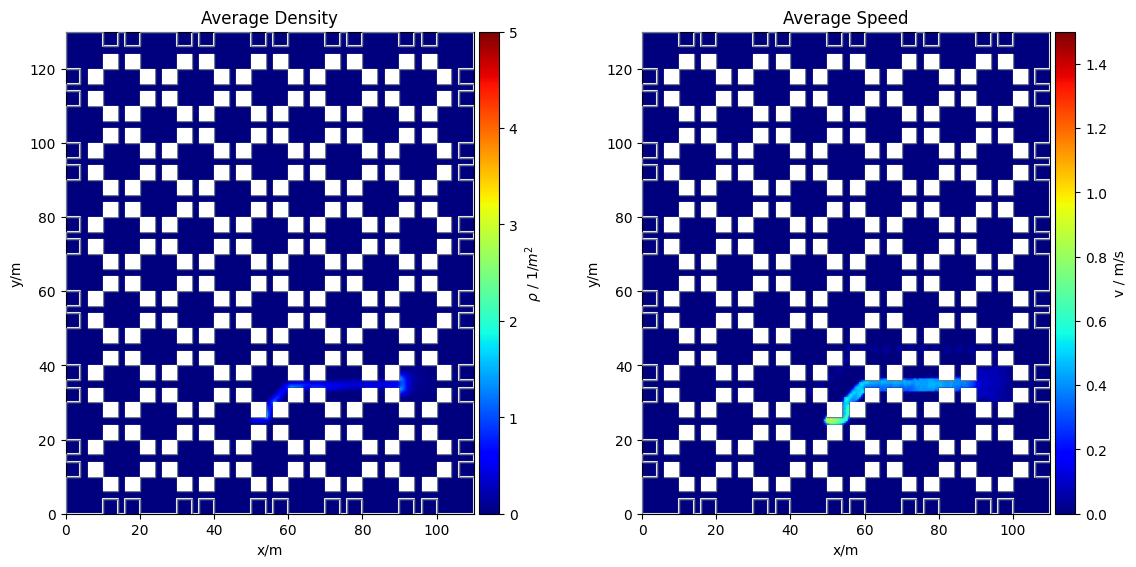

In [22]:
# สร้างพื้นที่สำหรับ 2 กราฟ (ซ้าย: Density, ขวา: Speed)
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

# 1. พล็อตค่าเฉลี่ยความหนาแน่น (Mean Density)
cm0 = pedpy.plot_profiles(
    walkable_area=walkable_area,
    profiles=[mean_density_map], # ใส่เป็น List เพราะฟังก์ชันต้องการ Sequence
    axes=ax0,
    label="$\\rho$ / 1/$m^2$",
    vmin=0,
    vmax=5,  # ปรับลดจาก 10 เหลือ 5 จะเห็นสีชัดขึ้นสำหรับค่าเฉลี่ย
    title="Average Density",
)

# 2. พล็อตค่าเฉลี่ยความเร็ว (Mean Speed)
# หมายเหตุ: ต้องมั่นใจว่าคุณทำลูปบวกสะสม speed_profiles มาเป็น mean_speed_map แล้ว
cm1 = pedpy.plot_profiles(
    walkable_area=walkable_area,
    profiles=[mean_speed_map], # ใส่เป็น List
    axes=ax1,
    label="v / m/s",
    vmin=0,
    vmax=1.5, # ความเร็วเดินปกติมักไม่เกิน 1.5 m/s
    title="Average Speed",
)

fig.tight_layout(pad=3)
plt.show()